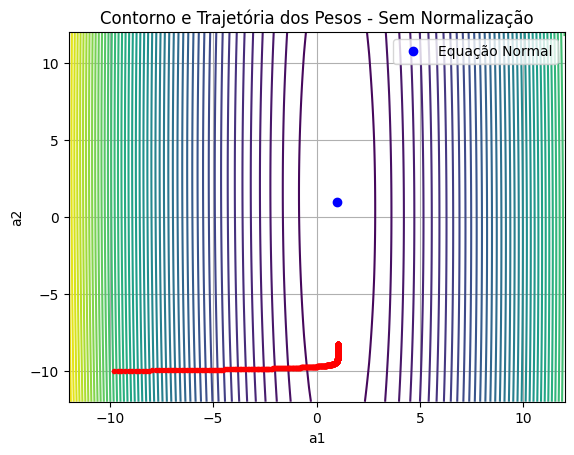

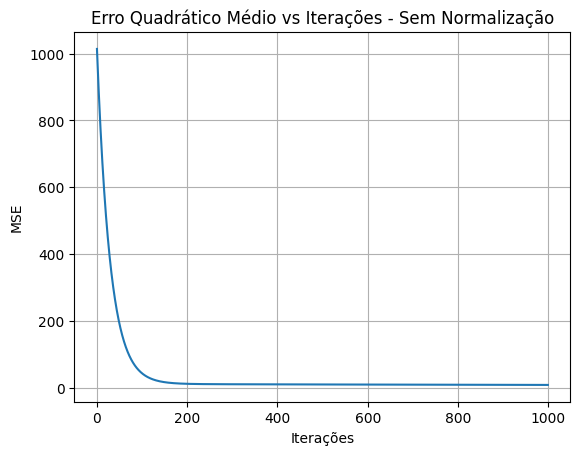

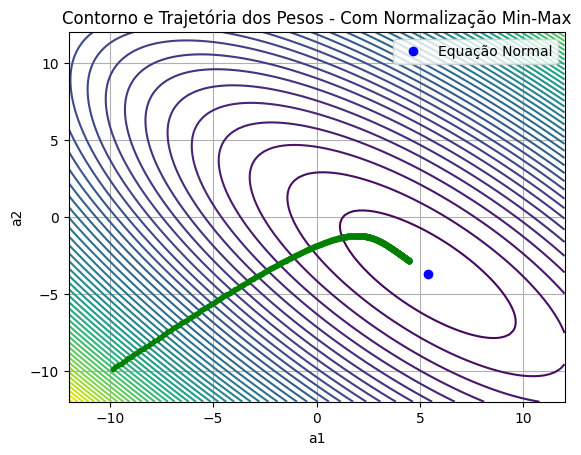

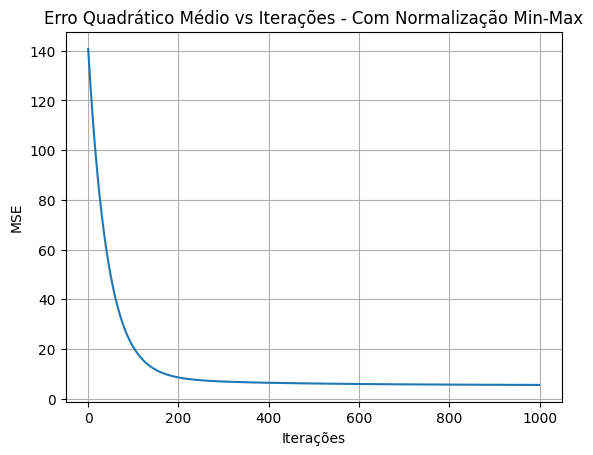

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Configurações iniciais
np.random.seed(42)
M = 1000

# Gerar dados
x1 = np.random.uniform(-5, 5, M)
x2 = np.random.uniform(-0.5, 0.5, M)
w = np.random.randn(M)
y_noisy = x1 + x2 + w

X = np.c_[x1, x2].astype(np.float64)
Y = y_noisy.reshape(-1, 1).astype(np.float64)

# Funções auxiliares
def compute_mse(X, Y, a):
    y_pred = X @ a
    mse = np.mean((Y - y_pred) ** 2)
    return mse

def plot_surface(X, Y):
    a1_range = np.linspace(-12, 12, 100)
    a2_range = np.linspace(-12, 12, 100)
    A1, A2 = np.meshgrid(a1_range, a2_range)
    MSE_surface = np.zeros_like(A1)

    for i in range(A1.shape[0]):
        for j in range(A1.shape[1]):
            a_tmp = np.array([[A1[i, j]], [A2[i, j]]])
            MSE_surface[i, j] = compute_mse(X, Y, a_tmp)

    return A1, A2, MSE_surface

def min_max_scaler(X):
    return (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

# Treinamento com GDE
def train_gde(X, Y, alpha, max_epochs=1000):
    a = np.array([[-10.0], [-10.0]])  # Corrigido para float
    errors = []
    a1_updates = []
    a2_updates = []

    for epoch in range(max_epochs):
        y_pred = X @ a
        error = y_pred - Y
        grad = (2/M) * X.T @ error

        a -= alpha * grad

        mse = compute_mse(X, Y, a)
        errors.append(mse)
        a1_updates.append(a[0,0])
        a2_updates.append(a[1,0])

    return a, errors, a1_updates, a2_updates

# Parte (a) - Sem Normalização
A1, A2, MSE_surface = plot_surface(X, Y)

# Encontrar melhor alpha manualmente
alpha = 0.001

a_gde, errors_gde, a1_updates_gde, a2_updates_gde = train_gde(X, Y, alpha)

# Solução analítica
A_closed = np.linalg.inv(X.T @ X) @ X.T @ Y

# Plots
plt.figure()
plt.contour(A1, A2, MSE_surface, levels=50)
plt.plot(a1_updates_gde, a2_updates_gde, 'r.-')
plt.plot(A_closed[0,0], A_closed[1,0], 'bo', label='Equação Normal')
plt.title('Contorno e Trajetória dos Pesos - Sem Normalização')
plt.xlabel('a1')
plt.ylabel('a2')
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(errors_gde)
plt.title('Erro Quadrático Médio vs Iterações - Sem Normalização')
plt.xlabel('Iterações')
plt.ylabel('MSE')
plt.grid()
plt.show()

# Parte (b) - Com Normalização Min-Max
X_scaled = min_max_scaler(X)

A1_scaled, A2_scaled, MSE_surface_scaled = plot_surface(X_scaled, Y)

# Encontrar melhor alpha manualmente para os dados normalizados
alpha_scaled = 0.01

a_gde_scaled, errors_gde_scaled, a1_updates_scaled, a2_updates_scaled = train_gde(X_scaled, Y, alpha_scaled)

# Solução analítica com dados normalizados
A_closed_scaled = np.linalg.inv(X_scaled.T @ X_scaled) @ X_scaled.T @ Y

# Plots
plt.figure()
plt.contour(A1_scaled, A2_scaled, MSE_surface_scaled, levels=50)
plt.plot(a1_updates_scaled, a2_updates_scaled, 'g.-')
plt.plot(A_closed_scaled[0,0], A_closed_scaled[1,0], 'bo', label='Equação Normal')
plt.title('Contorno e Trajetória dos Pesos - Com Normalização Min-Max')
plt.xlabel('a1')
plt.ylabel('a2')
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(errors_gde_scaled)
plt.title('Erro Quadrático Médio vs Iterações - Com Normalização Min-Max')
plt.xlabel('Iterações')
plt.ylabel('MSE')
plt.grid()
plt.show()



# c)
Sim, existe diferença clara.
Sem normalização, a superfície de erro é alongada, formando contornos bem esticados, especialmente no eixo a2. Isso ocorre porquex1 e x2 têm escalas muito diferentes, o que faz com que o gradiente desça lentamente em uma direção e rapidamente na outra (efeito de vales estreitos).
Com normalização min-max, a superfície ficou mais simétrica e arredondada, facilitando o caminho do gradiente e permitindo uma descida mais equilibrada em ambas as direções.

#d)
Sim, houve uma pequena diminuição.
Embora em ambos os casos a convergência tenha sido rápida no começo, com normalização o erro quadrático médio desceu de forma mais suave e estável, sem grandes oscilações iniciais.
Sem normalização, o gradiente teve dificuldade maior no início (a trajetória pareceu mais travada e menos eficiente), exigindo mais correções para alinhar-se com o mínimo.

#e)
Se aplicássemos padronização (standardization, ou seja, média zero e desvio padrão um para cada feature), o formato da superfície de erro também ficaria mais simétrico e arredondado, semelhante ao que ocorreu com a normalização.
A padronização também facilitaria a descida do gradiente, diminuindo o número de iterações necessárias para a convergência, pois as dimensões do problema ficariam proporcionais e o gradiente teria uma trajetória mais direta até o mínimo.